# blender-tissue-cartography

> Extract surfaces from volumetric microscopy data and map image data to 2D using Blender

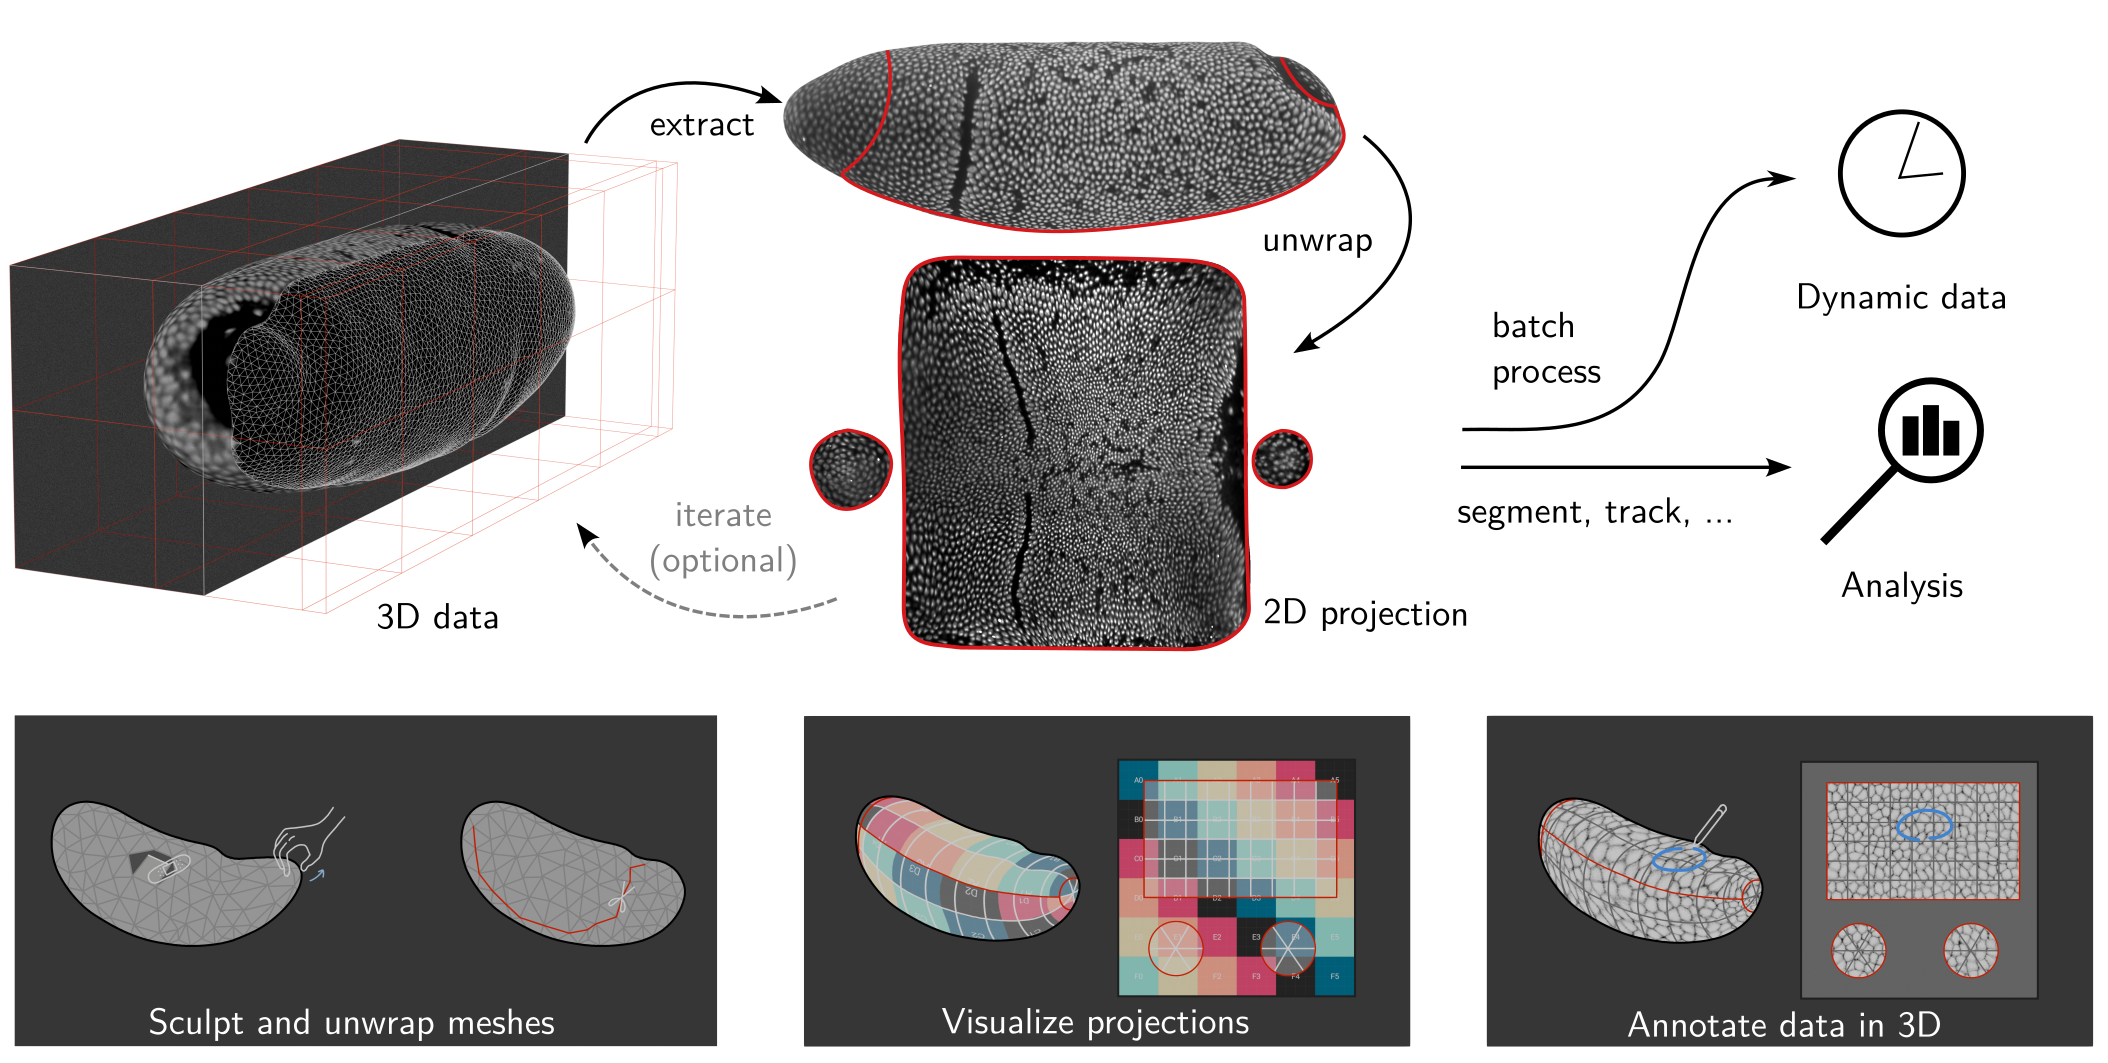

Tissue cartography extracts and cartographically projects curved surfaces from volumetric image data. This turns your 3D data into 2D data, which is much easier to visualize, analyze, and computationally process. 
Tissue cartography takes advantage of the laminar, sheet-like organization of many biological tissues. For more on tissue cartography, see our [methods paper](https://www.biorxiv.org/content/10.1101/2025.02.04.636523v1) and [Heemskerk & Streichan 2015](https://doi.org/10.1038/nmeth.3648).

This repository contains two tissue-cartography tools:

1. An add-on for the 3d creation software [blender](https://www.blender.org/) to do tissue cartography 100% in an interactive, graphical user interface. Use the add-on to quickly process a new dataset, or if you are not a coding expert.

2. A Python library for custom and automatized analysis pipelines. The library is available on [pip](https://pypi.org/project/blender-tissue-cartography/), and as source in [https://github.com/nikolas-claussen/blender-tissue-cartography/tree/main/blender_tissue_cartography](this directory of the repo).

#### Click here for a [2-minute video demo](https://youtu.be/Y3Vb6IDv0g0)

#### News and updates

- Version 2 of the Blender add-on is now available for download.

## Installation

**System requirements**

Processing volumetric image data requires sufficient RAM (at least ~4x of the size of the image). Blender will run _much_ faster if your computer has a GPU.

### Blender add-on

1. Install [Blender 4.2 or later](https://www.blender.org/) (pre-4.2 version will _not_ work)

     - Optional: install [Fiji](https://fiji.sc/) (for looking at 3D `.tif`s) and [Ilastik](https://www.ilastik.org/) (for 3D segmentation).

2. Download the add-on `.zip` from [GitHub](https://github.com/nikolas-claussen/blender-tissue-cartography/tree/main/blender_addon_download). Choose the file that matches your operating system (e.g. `linux_x64`). 
    - If your OS is unavailable, download the [add-on source code](https://github.com/nikolas-claussen/blender-tissue-cartography/tree/main/blender_addon_src), and install the python library `scikit-image` in Blender's Python interface.

3. [Install the add-on](https://docs.blender.org/manual/en/latest/editors/preferences/addons.html): Click "Edit ->  Preferences -> Add-ons -> Add-on Settings -> Install from disk" and select the `.zip` file you just downloaded.

4. Restart Blender. The add-on is under "Scene -> Tissue Cartography".

### Python library

1. Optional: Install [Blender 4.2 or later](https://www.blender.org/)
    - Some workflows also require [Fiji](https://fiji.sc/), [Ilastik](https://www.ilastik.org/), or [Meshlab](https://www.meshlab.net/).

2. Install `blender-tissue-cartography` from pip: run `pip install blender-tissue-cartography` in a command window.
 
3. (Optional) Install the Python library for `pymeshlab` for advanced (re)meshing functionality. Run `pip install pymeshlab` in a command window

### Developer instructions 

To extend the `blender-tissue-cartography` **Blender add-on**:

1. Download the add-on source code from [https://github.com/nikolas-claussen/blender-tissue-cartography/tree/main/blender_addon_src](GitHub).

2. Read the [https://github.com/nikolas-claussen/blender-tissue-cartography/blob/main/blender_addon_src/DEVELOPER_README.md](add-on developer readme).


To extend the `blender-tissue-cartography` **Python library**:

1. [Clone](https://docs.github.com/en/repositories/creating-and-managing-repositories/cloning-a-repository) the [github repository](https://github.com/nikolas-claussen/blender-tissue-cartography).

2. Create a `conda` environment and install the `blender_tissue_cartography` module. In a command window:
    - `conda env create -n blender_tissue_cartography -f environment.yml` 
    - `conda activate blender_tissue_cartography`
    - `pip install -e .`
    
3. Install [nbdev](https://nbdev.fast.ai/). The python library is developed in Jupyter notebooks that are exported to Python modules and the documentation webpage.

## Documentation

- [Documentation webpage](https://nikolas-claussen.github.io/blender-tissue-cartography/). Datasets and interactive Jupyter notebooks for the tutorials can be downloaded [from GitHub](https://github.com/nikolas-claussen/blender-tissue-cartography/tree/main/nbs/Tutorials/)

- The [methods paper](https://www.biorxiv.org/content/10.1101/2025.02.04.636523v1) explains the basics of tissue cartography, the design of `blender_tissue_cartography`, and shows several examples.

### Troubleshooting

- 3D `.tif` files loaded into Blender are not saved to disk. If you close Blender, you need to reload your 3D image data.

- Check the "shape" of 3D data loaded into the add-on (image bounding box). If it is off, adjust the axis order and spatial resolution.

- Save your `.blend` project to disk before using the add-on. Otherwise, Blender may crash.

- Please report any bugs on GitHub!

## Usage

For details, see the [documentation](https://nikolas-claussen.github.io/blender-tissue-cartography/00_tissue_cartography_overview.html#tutorials).

### Tissue cartography workflow

The workflow starts with a 3D, volumetric image, and a 3D segmentation of the object you want to extract. 
This repo does not contain any image segmentation tools as excellent software is already available (e.g. [Ilastik](https://www.ilastik.org/))

1. Convert the 3D segmentation into a surface

2. Cartographically unwrap the surface into a 2D plane (UV mapping)

3. Project your 3D data to 2D

4. Visualize the results in 2D or 3D, and use the 2D projections for quantitative analysis

5. Batch process multiple 3D images (e.g. frames of a movie)

#### Advanced usage: Dynamic datasets

In dynamic datasets (i.e., movies), the surface of interest can move or deform over time. Alternatively, you may want to align recordings of multiple samples. The add-on and library also provide tools for this more complex use case.
You create a cartographic projection for a _reference time point_ which is aligned to all other time points using surface-to-surface registration algorithms. This generates consistent projections across multiple frames or samples.

### Blender add-on

The add-on can carry out steps 1-5 entirely within Blender, so you can edit meshes and cartographic projections interactively. Here is a screenshot using the example [_Drosophila_ blastoderm dataset](https://github.com/nikolas-claussen/blender-tissue-cartography/blob/main/nbs/Tutorials/addon_example/Drosophila_CAAX-mCherry.tif):

![image.png](../index_files/addon_screenshot.png)

Left: Projected 2D image. Center: 3D view of image data (volume bounding box, image slices, and extracted surface). Right: Tissue Cartography add-on panel. 

### `blender_tissue_cartography` Python library

With the Python library you can build automated tissue cartography pipelines. The library also has tools for quantitative image analysis on projections (namely, to mathematically account for **cartographic distortion**).



## Other useful software for tissue cartography

- [Meshlab](https://www.meshlab.net/): GUI and [Python library](https://pymeshlab.readthedocs.io/en/latest/index.html) with advanced remeshing and surface reconstruction tools.
- [MicroscopyNodes](https://github.com/oanegros/MicroscopyNodes): plug-in for rendering volumetric `.tif` files in blender
- [Boundary First Flattening](https://github.com/GeometryCollective/boundary-first-flattening): advanced tool for creating UV maps with graphical and command line interface

## Citation

If you use `blender_tissue_cartography` for your work, please cite:

> Nikolas Claussen, Cécile Regis, Susan Wopat, and Sebastian Streichan: _Blender tissue cartography: an intuitive tool for the analysis of dynamic 3D microscopy data_. bioRxiv 2025.02.04.636523; doi: https://doi.org/10.1101/2025.02.04.636523


### Acknowledgements

This software is being developed by [Nikolas Claussen](https://pcts.princeton.edu/people/nikolas-claussen). 
We thank Susan Wopat, Matthew Lefebvre (members of [Streichan lab at UCSB](https://streichanlab.physics.ucsb.edu/)), Cecile Regis, Noah Mitchell, An Yan, Pieter Derksen, Matthew Lefebvre, Sean Komura, Gary Han, Boris Fosso, and Dillon Cislo for sharing data, advice, and software testing.